In [26]:
from xsynth.main import SetKicker
from xsynth.device import (KL2005, KMX1938, KMX1965, KNY1938, KNY1965)

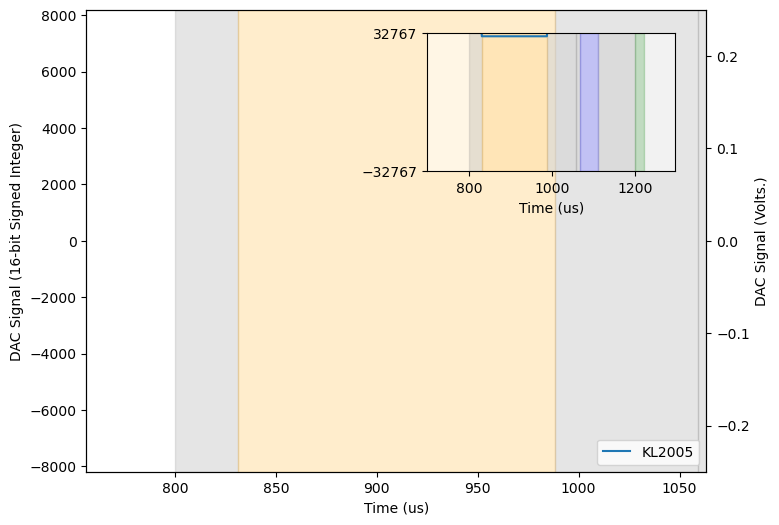

In [27]:
S = SetKicker(KL2005,
          0.95,
          beamline = '2',
          display = True)

In [ ]:
import numpy as np
from scipy.optimize import minimize_scalar

def value_function(kick):
    # Example value function; replace this with your actual function.
    # This example is quadratic with a peak for demonstration.
    return -(kick - 5) ** 2 + 20  # Peaks at kick = 5 for illustration

def optimize_kick(scan_start=0, scan_end=10, initial_guess=None):
    """
    Optimizes the 'kick' variable within a specified scan range.

    Parameters:
        scan_start (float): Lower bound of the scan range for 'kick'.
        scan_end (float): Upper bound of the scan range for 'kick'.
        initial_guess (float, optional): Initial guess for 'kick'.
        
    Returns:
        tuple: Optimal kick value and the maximum value of the function.
    """
    # Print input information for user confirmation
    print(f"Scanning from {scan_start} to {scan_end}")
    if initial_guess is not None:
        print(f"Initial guess: {initial_guess}")

    # Minimize -value_function to maximize value_function
    result = minimize_scalar(
        lambda kick: -value_function(kick),
        bounds=(scan_start, scan_end),
        method='bounded'
    )

    # Extract optimal results
    optimal_kick = result.x
    max_value = value_function(optimal_kick)
    
    return optimal_kick, max_value

# User inputs for scan range
try:
    scan_start = float(input("Enter the start of the scan range: "))
    scan_end = float(input("Enter the end of the scan range: "))
    initial_guess = input("Enter an initial guess for kick (optional): ")
    initial_guess = float(initial_guess) if initial_guess else None
except ValueError:
    print("Invalid input. Please enter numeric values.")
    scan_start, scan_end, initial_guess = 0, 10, None  # Default values as fallback

# Run the optimization with user-defined inputs
optimal_kick, max_value = optimize_kick(scan_start, scan_end, initial_guess)
print(f"Optimal kick value: {optimal_kick}")
print(f"Maximum value function at optimal kick: {max_value}")


In [ ]:
import pydoocs


pulse_energy = 0
number_of_trains = 10
n = 0

while n <= number_of_trains:
    pydoocs.connect(['XFEL.FEL/XGM/XGM.2595.T6/INTENSITY.TD'])
    data = pydoocs.getdata()
    #print(data)
    if data is None:
        pass
    elif data is not None:
        n += 1
        pulse_energy += data[0]['data'][:, 1].mean()
    pydoocs.connect
pulse_energy /= number_of_trains

KeyboardInterrupt: 

In [23]:
import pydoocs
pydoocs.connect(['XFEL.FEL/XGM/XGM.2595.T6/INTENSITY.TD'], cycles = 10)
a = pydoocs.getdata()

In [24]:
a